## Khai bao thu vien


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
import os
from matplotlib.colors import SymLogNorm
from matplotlib.colors import Normalize
plt.style.use('sci.mplstyle')

## Ham RK4 duoc ma tran hoa

In [3]:
def RK4_he(a, b, N, alpha, phuongtrinh):
    h = (b - a) / N
    x = []
    y = []

    x.append(a)
    y.append(np.array(alpha, dtype=float))

    for i in range(1, N + 1):
        x_i = x[i-1]
        y_i = y[i-1]

        x.append(a + i*h)

        k1 = h * np.array(phuongtrinh(x_i, y_i))
        k2 = h * np.array(phuongtrinh(x_i + h/2, y_i + k1/2))
        k3 = h * np.array(phuongtrinh(x_i + h/2, y_i + k2/2))
        k4 = h * np.array(phuongtrinh(x_i + h,   y_i + k3))

        y_moi = y_i + (k1 + 2*k2 + 2*k3 + k4)/6
        y.append(y_moi)
    return x, y

## Nem xien khong ma sat

In [4]:
g = 9.81

def phuong_trinh_nemxien_khongmasat(t,Y):
    global g
    x, y, vx, vy = Y

    dxdt = vx
    dydt = vy
    dvxdt = 0.0
    dvydt = -g
    return [dxdt, dydt, dvxdt, dvydt]

def nemxien_khongmasat(x0, y0, v0, theta, N):
    global g
    theta_rad = np.radians(theta)

    vx0 = v0 * np.cos(theta_rad)
    vy0 = v0 * np.sin(theta_rad)

    a = 0.0
    b = 2 * vy0 / 9.8 + 1.0

    alpha = [x0, y0, vx0, vy0]

    t, Y = RK4_he(a, b, N, alpha, phuong_trinh_nemxien_khongmasat)

    # Tach cac thanh phan
    x = [row[0] for row in Y]
    y = [row[1] for row in Y]
    vx = [row[2] for row in Y]
    vy = [row[3] for row in Y]

    t_cal = np.array(t)

    y_calculus = y0 + vy0*t_cal - 0.5 * 9.8 * t_cal**2
    x_calculus = x0 + vx0*t_cal

    return t, x, y, vx, vy, x_calculus, y_calculus

# Code ve cho hinh 1 trong file 

In [5]:
# Hinh 1a: goc nem: 15 30 50 do

x0 = 0
y0 = 0
v0 = 20

theta = [15,30,50]

for j in range(len(theta)):
    with open("data_1a_theta" + str(theta[j]) + ".dat", "w", encoding="utf-8") as f:
        f.write("# Data hinh 1a\n")
        f.write("#" * 120 + "\n")
        f.write(f"#{'i':>5s} {'t':>12s} {'x':>12s} {'y':>12s} {'vx':>12s} {'vy':>12s} {'x_calculus':>12s} {'y_calculus':>12s}\n")
        t, x, y, vx, vy, x_calculus, y_calculus = nemxien_khongmasat(x0=0, y0=0, v0=20, theta=theta[j], N=1000)
        for i in range(len(x)):
            f.write(f" {i:5d} {t[i]:12.6f} {x[i]:12.6f} {y[i]:12.6f} {vx[i]:12.6f} {vy[i]:12.6f} {x_calculus[i]:12.6f} {y_calculus[i]:12.6f}\n")

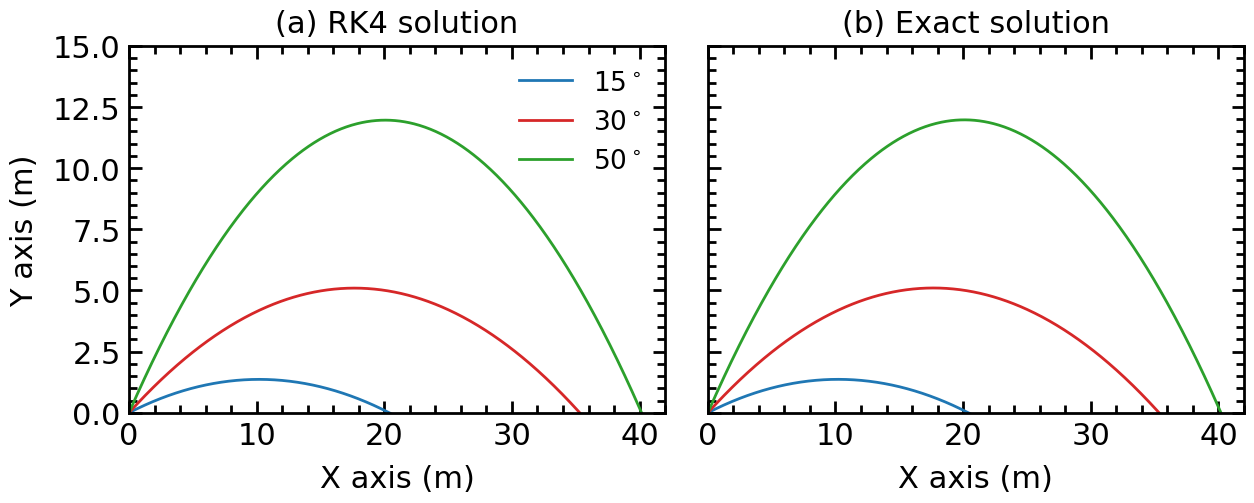

In [6]:
x_15, y_15, x_15_cal, y_15_cal = np.loadtxt("data_1a_theta15.dat", unpack=True, usecols=(2,3,6,7), comments="#")
x_30, y_30, x_30_cal, y_30_cal = np.loadtxt("data_1a_theta30.dat", unpack=True, usecols=(2,3,6,7), comments="#")
x_50, y_50, x_50_cal, y_50_cal = np.loadtxt("data_1a_theta50.dat", unpack=True, usecols=(2,3,6,7), comments="#")

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# Hinh (a): RK4 solution
axes[0].plot(x_15, y_15, color="C0", label=r"15$^\circ$")
axes[0].plot(x_30, y_30, color="C1", label=r"30$^\circ$")
axes[0].plot(x_50, y_50, color="C2", label=r"50$^\circ$")
axes[0].set_ylim(0, 15)
axes[0].set_xlim(0, 42)
axes[0].set_xlabel("X axis (m)")
axes[0].set_ylabel("Y axis (m)")
axes[0].legend()
axes[0].set_title("(a) RK4 solution")

# Hinh (b): Exact solution
axes[1].plot(x_15_cal, y_15_cal, color="C0", label=r"15$^\circ$")
axes[1].plot(x_30_cal, y_30_cal, color="C1", label=r"30$^\circ$")
axes[1].plot(x_50_cal, y_50_cal, color="C2", label=r"50$^\circ$")
axes[1].set_ylim(0, 15)
axes[1].set_xlim(0, 42)
axes[1].set_xlabel("X axis (m)")
#axes[1].set_ylabel("Y axis (m)")
axes[1].set_yticklabels([])
axes[1].set_title("(b) Exact solution")

plt.tight_layout()
plt.savefig("1.pdf")
plt.show()

## Ham tinh max range, height va flight time (cho hinh 2 trong file)

In [7]:
# Dung de tinh max range, max height va thoi gian bay dua vao toa do roi rac
def tinh_max_range_height_time(t, x, y):
    t = np.asarray(t, dtype=float)
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    H = np.max(y)

    t_impact = None
    R = None

    for i in range(len(y) - 1):
        if y[i] > 0 and y[i + 1] <= 0:
            # Noi suy tuyen tinh cho impact time
            t_impact = t[i] + (t[i + 1] - t[i]) * y[i] / (y[i] - y[i + 1])

            # Noi suy tuyen tinh cho range
            R = x[i] + (x[i + 1] - x[i]) * y[i] / (y[i] - y[i + 1])
            break

    return R, H, t_impact

# Dung de tinh max range, max height va thoi gian bay dua vao nghiem giai tich

def R_H_t_calculus(theta, v0):
    global g

    theta_rad = np.radians(theta)

    R = v0**2 * np.sin(2 * theta_rad) / g
    H = v0**2 * np.sin(theta_rad)**2 / (2 * g)
    t_impact = 2 * v0 * np.sin(theta_rad) / g

    return R, H, t_impact

# Du lieu cho bang I 

In [8]:
theta = np.linspace(0.1,89.9,100)
v0 = 20

with open("data_1cd_theta.dat", "w", encoding="utf-8") as f:
    f.write("# Data hinh 1c\n")
    f.write("#" * 120 + "\n")
    f.write(f"#{'i':>5s} {'theta':>12s} {'R':>12s} {'H_max':>12s} {'T': >12s} {'R_calculus':>12s} {'H_max_calculus':>12s} {'T_cal':>12s}\n")
    for i in range(len(theta)):
        t, x, y, vx, vy, x_calculus, y_calculus = nemxien_khongmasat(x0=0, y0=0, v0=v0, theta=theta[i], N=1000)
        R_RK4, H_RK4, time_RK4 = tinh_max_range_height_time(t,x,y)
        R_cal, H_cal, time_cal = R_H_t_calculus(theta[i], v0)
        f.write(f" {i:5d} {theta[i]:12.6f} {R_RK4:12.6f} {H_RK4:12.6f} {time_RK4:12.6f} {R_cal:12.6f} {H_cal:12.6f} {time_cal:12.6f}\n")

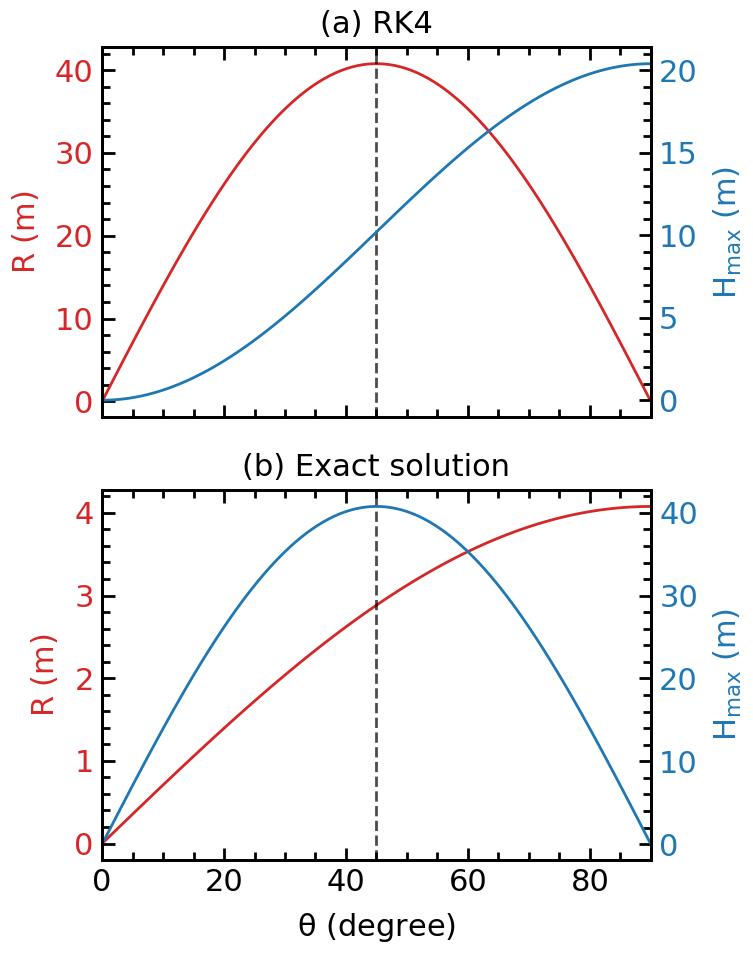

In [9]:
theta, R, H_max, R_calculus, H_max_calculus = np.loadtxt("data_1cd_theta.dat", unpack=True, usecols=(1,2,3,4,5), comments="#")

fig, axes = plt.subplots(2, 1, figsize=(8, 10))

# =========================
# RK4 / numerical
# =========================
ax1 = axes[0]
ax1_r = ax1.twinx()

line1, = ax1.plot(theta, R, color='C1', label='R')
line2, = ax1_r.plot(theta, H_max, color='C0', label=r'$H_{\max}$')

#ax1.set_xlabel(r'$\theta$ (degree)')
ax1.tick_params(axis='x', labelbottom=False)
ax1.set_ylabel(r'$R$ (m)', color='C1')
ax1_r.set_ylabel(r'$H_{\max}$ (m)', color='C0')

ax1.tick_params(axis='y', labelcolor='C1')
ax1_r.tick_params(axis='y', labelcolor='C0')
ax1.set_xlim(0,90)
ax1.axvline(45, linestyle = '--', color = 'black', alpha = 0.7)

ax1.set_title('(a) RK4')


# =========================
# analytical
# =========================
ax2 = axes[1]
ax2_r = ax2.twinx()

line3, = ax2.plot(theta, R_calculus, color='C1',  label=r'$R_{\mathrm{calculus}}$')
line4, = ax2_r.plot(theta, H_max_calculus, color='C0',  label=r'$H_{\max,\mathrm{calculus}}$')

ax2.set_xlabel(r'$\theta$ (degree)')
ax2.set_ylabel(r'$R$ (m)', color='C1')
ax2_r.set_ylabel(r'$H_{\max}$ (m)', color='C0')

ax2.tick_params(axis='y', labelcolor='C1')
ax2_r.tick_params(axis='y', labelcolor='C0')

ax2.set_title('(b) Exact solution')
ax2.set_xlim(0,90)
ax2.axvline(45, linestyle = '--', color = 'black', alpha = 0.7)



plt.tight_layout()
plt.savefig('2.pdf')
plt.show()

## Ham co ma sat

In [10]:
# ---------------------------------------------------------
# CÓ MA SÁT
# ---------------------------------------------------------
def phuong_trinh_nemxien_comasat(t, Y, k, n):
    global g
    x, y, vx, vy = Y
    
    v = np.sqrt(vx**2 + vy**2)

    dxdt = vx
    dydt = vy

    if v == 0:
        fx = 0.0
        fy = 0.0
    else:
        fx = -k * (v**(n-1)) * vx
        fy = -k * (v**(n-1)) * vy

    dvxdt = fx
    dvydt = fy - g
        
    return [dxdt, dydt, dvxdt, dvydt, fx, fy]

def nemxien_comasat(x0, y0, v0, theta, k, n, N):
    global g
    theta_rad = np.radians(theta)

    vx0 = v0 * np.cos(theta_rad)
    vy0 = v0 * np.sin(theta_rad)

    a = 0.0
    b = 2 * vy0 / g + 1.0

    alpha = [x0, y0, vx0, vy0]

    func = lambda t, Y: phuong_trinh_nemxien_comasat(t, Y, k, n)[:4]

    t, Y = RK4_he(a, b, N, alpha, func)

    x  = [row[0] for row in Y]
    y  = [row[1] for row in Y]
    vx = [row[2] for row in Y]
    vy = [row[3] for row in Y]

    fx = []
    fy = []
    for i in range(len(t)):
        ketqua = phuong_trinh_nemxien_comasat(t[i], [x[i], y[i], vx[i], vy[i]], k, n)
        fx.append(ketqua[4])
        fy.append(ketqua[5])

    t_cal = np.array(t)
    
    return t, x, y, vx, vy, fx, fy

# Code de ve hinh 3 trong file latex

In [11]:
x0 = 0
y0 = 0
v0 = [10,20,50]

k_friction = [0,0.8]
n_power = [1,1.5,2]

theta = [15, 30, 50]

for q in range(len(v0)):
    for j in range(len(n_power)):
        filename = "data_3ab_comasat_npower_" + str(n_power[j]) + "_v0_" + str(v0[q]) + ".dat"
        with open(filename, "w", encoding="utf-8") as f:
            f.write(f"# Data hinh 1a (Co ma sat va khong ma sat, n={n_power})\n")
            f.write("#" * 120 + "\n")
            f.write(f"#{'i':>5s} {'t':>12s} {'x':>12s} {'y':>12s} {'vx':>12s} {'vy':>12s} {'f_x':>12s} {'f_y':>12s}\n")
            
            t_masat, x_masat, y_masat, vx_masat, vy_masat, fx_masat, fy_masat = nemxien_comasat(x0, y0, v0[q], theta[1], k_friction[1], n_power[j], N=1000)
            for i in range(len(x_masat)):
                f.write(f" {i:5d} {t_masat[i]:12.6f} {x_masat[i]:12.6f} {y_masat[i]:12.6f} {vx_masat[i]:12.6f} {vy_masat[i]:12.6f} {fx_masat[i]:12.6f} {fy_masat[i]:12.6f}\n")
    
    filename2 = "data_3ab_khongmasat_npower_" + str(n_power[0]) + "_v0_" + str(v0[q]) + ".dat"
    with open(filename2, "w", encoding="utf-8") as f:
            f.write(f"# Data hinh 1a (Co ma sat va khong ma sat, n={n_power})\n")
            f.write("#" * 120 + "\n")
            f.write(f"#{'i':>5s} {'t':>12s} {'x':>12s} {'y':>12s} {'vx':>12s} {'vy':>12s} {'f_x':>12s} {'f_y':>12s}\n")
            t_khong_masat, x_khong_masat, y_khong_masat, vx_khong_masat, vy_khong_masat, fx_khong_masat, fy_khong_masat = nemxien_comasat(x0, y0, v0[q], theta[1], k_friction[0], n_power[0], N=1000)
            for i in range(len(x_khong_masat)):
                f.write(f" {i:5d} {t_khong_masat[i]:12.6f} {x_khong_masat[i]:12.6f} {y_khong_masat[i]:12.6f} {vx_khong_masat[i]:12.6f} {vy_khong_masat[i]:12.6f} {fx_khong_masat[i]:12.6f} {fy_khong_masat[i]:12.6f}\n")
                
    

C:\Users\admin\AppData\Local\Temp\ipykernel_23696\3193645157.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


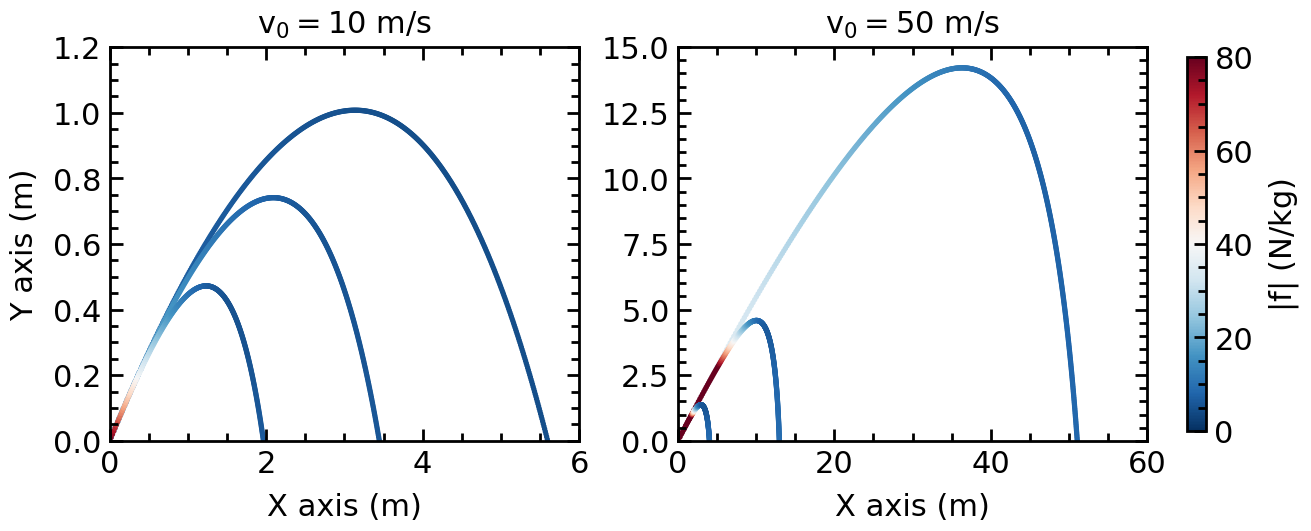

In [12]:
def docdata_vehinha(v0_value, n_value):
    filename = f"data_3ab_comasat_npower_{n_value}_v0_{v0_value}.dat"
    x, y, fx, fy = np.loadtxt(
        filename,
        unpack=True,
        usecols=(2, 3, 6, 7),
        comments="#"
    )
    return x, y, fx, fy

n_power_list = [1, 1.5, 2]
v0_list = [10, 50]

line_styles = ['-', '--', ':']
labels = [r'$n=1$', r'$n=1.5$', r'$n=2$']
norm = Normalize(vmin=0, vmax=80)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.2), constrained_layout=True)

sc = None

for ax, v0_value in zip(axes, v0_list):
    for n, ls, lab in zip(n_power_list, line_styles, labels):
        x, y, fx, fy = docdata_vehinha(v0_value, n)
        f_mag = np.sqrt(fx**2 + fy**2)

        sc = ax.scatter(
            x, y,
            c=f_mag,
            cmap='RdBu_r',
            norm=norm,
            s=8,
            alpha=1
        )

    ax.set_xlabel('X axis (m)')
    ax.set_title(rf'$v_0={v0_value}$ m/s')
    ax.legend()

axes[0].set_ylabel('Y axis (m)')
axes[0].set_xlim(0, 6)
axes[0].set_ylim(0, 1.2)

axes[1].set_xlim(0, 60)
axes[1].set_ylim(0, 15)

cbar = fig.colorbar(sc, ax=axes, pad=0.02, shrink=0.95)
cbar.set_label(r'$|f|$ (N/kg)')
plt.savefig("3.pdf")
plt.show()

# Code de ve hinh 4a/4b/4c 

In [13]:

v0_list = [10, 50]       
theta = np.linspace(0.1, 89.9, 100)
k_val = 0.8                 
n_power = [1, 1.5, 2]
x0 = 0
y0 = 0

# Khởi tạo Dictionary gom toàn bộ dữ liệu
data_dict = {}

for v in v0_list:
    data_dict[v] = {}
    
    # 1. Thu thập dữ liệu Lý thuyết (không ma sát) cho vận tốc v
    data_dict[v]['cal'] = {'R': [], 'H': [], 'T': []} 
    for th in theta:
        R_cal, H_cal, T_cal = R_H_t_calculus(th, v)   
        data_dict[v]['cal']['R'].append(R_cal)
        data_dict[v]['cal']['H'].append(H_cal)
        data_dict[v]['cal']['T'].append(T_cal)       
        
    # 2. Thu thập dữ liệu RK4 và TẠO FILE cho từng hệ số n
    for n in n_power:
        data_dict[v][n] = {'R': [], 'H': [], 'T': []} 
        
        # Chạy mô phỏng cho 100 góc theta
        for th in theta:
            t, x, y, _, _, _, _ = nemxien_comasat(x0, y0, v, th, k_val, n, 1000)
            R_RK4, H_RK4, T_RK4 = tinh_max_range_height_time(t, x, y) 
            
            data_dict[v][n]['R'].append(R_RK4)
            data_dict[v][n]['H'].append(H_RK4)
            data_dict[v][n]['T'].append(T_RK4)

        # ---------------------------------------------------------
        # 3. GHI FILE cac du lieu
        # ---------------------------------------------------------
        filename = f"data_4abc_comasat_v0_{v}_n_{n}.txt"
        
        with open(filename, "w", encoding="utf-8") as file:
            file.write(f"# Du lieu R, H, T cho van toc v = {v}, he so ma sat n = {n} \n")
            file.write("#" * 110 + "\n")
            # Căn lề các cột cho đẹp mắt (thêm cột theta để dễ track dữ liệu)
            file.write(f"# {'i':<5} {'theta (do)':<12} {'R':<15} {'R_cal':<15} {'H':<15} {'H_cal':<15} {'T':<15} {'T_cal':<15}\n")
            
            for i in range(len(theta)):
                # Lấy dữ liệu Lý thuyết
                R_c = data_dict[v]['cal']['R'][i]
                H_c = data_dict[v]['cal']['H'][i]
                T_c = data_dict[v]['cal']['T'][i]

                # Lấy dữ liệu Có ma sát (RK4)
                R_rk = data_dict[v][n]['R'][i]
                H_rk = data_dict[v][n]['H'][i]
                T_rk = data_dict[v][n]['T'][i]
                th_val = theta[i]

                file.write(f"  {i:<5} {th_val:<12.6f} {R_rk:<15.6f} {R_c:<15.6f} {H_rk:<15.6f} {H_c:<15.6f} {T_rk:<15.6f} {T_c:<15.6f}\n")

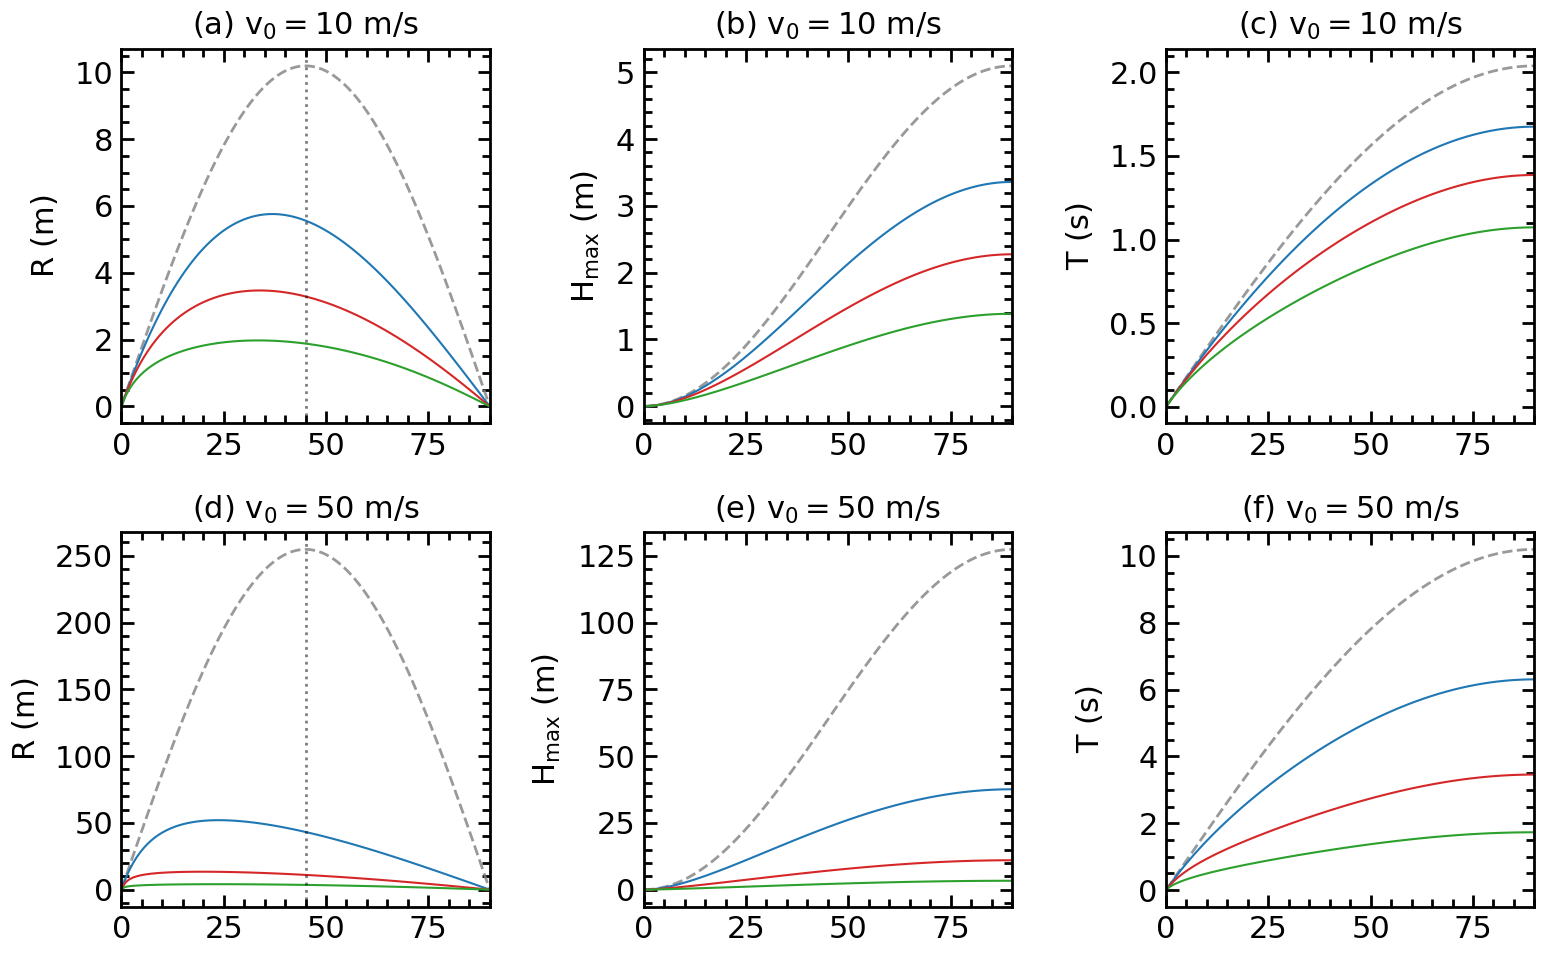

In [57]:
# Các thông số để tìm lại đúng tên file
v0_list = [10, 50]
n_power = [1, 1.5, 2]
colors = {1: 'C0', 1.5: 'C1', 2: 'C2'}

# Tạo khung hình 2 hàng (2 mức v0) x 3 cột (R, H, T)
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for i, v in enumerate(v0_list):
    # Gán các trục cho dễ gọi
    ax_R = axes[i, 0]
    ax_H = axes[i, 1]
    ax_T = axes[i, 2]

    # ---------------------------------------------------
    # 1. Vẽ đường Lý thuyết (Chỉ cần đọc từ 1 file bất kỳ vì lý thuyết giống nhau)
    # ---------------------------------------------------
    # Dùng np.loadtxt, tham số comments='#' sẽ tự động bỏ qua các dòng text chữ
    data_th = np.loadtxt(f"data_4abc_comasat_v0_{v}_n_1.txt", comments='#')
    
    # Lấy các cột dữ liệu lý thuyết (Cột 1 là theta, 3 là R_cal, 5 là H_cal, 7 là T_cal)
    theta_val = data_th[:, 1]
    
    ax_R.plot(theta_val, data_th[:, 3], '--', color='gray', alpha=0.8, label='Lý thuyết')
    ax_H.plot(theta_val, data_th[:, 5], '--', color='gray', alpha=0.8, label='Lý thuyết')
    ax_T.plot(theta_val, data_th[:, 7], '--', color='gray', alpha=0.8, label='Lý thuyết')

    # ---------------------------------------------------
    # 2. Đọc file và vẽ đường RK4 cho từng hệ số n
    # ---------------------------------------------------
    for n in n_power:
        filename = f"data_4abc_comasat_v0_{v}_n_{n}.txt"
        data = np.loadtxt(filename, comments='#')
        
        # Trích xuất các cột tương ứng (Cột 2 là R, 4 là H, 6 là T)
        R_val = data[:, 2]
        H_val = data[:, 4]
        T_val = data[:, 6]

        ax_R.plot(theta_val, R_val, color=colors[n], linewidth=1.5, label=f'n = {n}')
        ax_H.plot(theta_val, H_val, color=colors[n], linewidth=1.5, label=f'n = {n}')
        ax_T.plot(theta_val, T_val, color=colors[n], linewidth=1.5, label=f'n = {n}')

    # ---------------------------------------------------
    # 3. Trang trí đồ thị (Grid, Labels, Titles)
    # ---------------------------------------------------
    # Cột 1: Tầm xa R
    if v == 10:     
        ax_R.set_title(f'(a) $ v_0 = {v}$ m/s')
    else:
        ax_R.set_title(f'(d) $ v_0 = {v}$ m/s')
    ax_R.set_ylabel(r'$R$ (m)')
    ax_R.set_xlim(0, 90)
    ax_R.axvline(45, linestyle=':', color='black', alpha=0.5) # Đường 45 độ
    
    # Cột 2: Tầm cao H
    if v == 10:     
        ax_H.set_title(f'(b) $v_0 = {v}$ m/s')
    else:
        ax_H.set_title(f'(e) $v_0 = {v}$ m/s')
    ax_H.set_ylabel(r'$H_{\max}$ (m)')
    ax_H.set_xlim(0, 90)
    
    # Cột 3: Thời gian bay T
    if v == 10:     
        ax_T.set_title(f'(c) $ v_0 = {v}$ m/s')
    else:
        ax_T.set_title(f'(f) $ v_0 = {v}$ m/s')
    ax_T.set_ylabel(r'$T$ (s)')
    ax_T.set_xlim(0, 90)
    


    # Gắn trục X và Grid chung cho tất cả các ô ở hàng hiện tại
    # for ax in [ax_R, ax_H, ax_T]:
    #     ax.set_xlabel(r'$\theta$ (degree)')
        # ax.grid(True, linestyle=':', alpha=0.7)
        # ax.legend(fontsize=9)

# Thêm tiêu đề tổng cho toàn bộ Figure
# fig.suptitle('Sự phụ thuộc của R, H, T vào góc ném và hệ số lực cản', fontsize=16, fontweight='bold')

plt.tight_layout()
plt.savefig('4.pdf')
plt.show()

# code de ve hinh 4d va bang II

In [15]:

# Khởi tạo dictionary để lưu góc tối ưu cho phần vẽ đồ thị phía sau
optimal_data = {v: {} for v in v0_list}

with open("optimal_theta.txt", "w", encoding="utf-8") as file:
    for v in v0_list:
        file.write(f"=== KẾT QUẢ CHO v0 = {v} m/s ===\n")
        file.write("-" * 75 + "\n")
        file.write(f"{'Model':<10} | {'Theta_opt':<10} | {'R_max':<10} | {'H_max':<10} | {'T':<10} | {'Delta R (%)':<12} \n")
        file.write("-" * 75 + "\n")

        # ---------------------------------------------------
        # Xử lý trường hợp Lý thuyết (Không ma sát) cho v hiện tại
        # ---------------------------------------------------
        R_cal_list_v = data_dict[v]['cal']['R']
        H_cal_list_v = data_dict[v]['cal']['H']
        T_cal_list_v = data_dict[v]['cal']['T'] # Đảm bảo data_dict có lưu 'T' nhé

        idx_cal = np.argmax(R_cal_list_v) # Tìm vị trí có R lớn nhất
        theta_opt_cal = theta[idx_cal]
        R_max_cal = R_cal_list_v[idx_cal]
        H_opt_cal = H_cal_list_v[idx_cal]
        T_opt_cal = T_cal_list_v[idx_cal]

        file.write(f"{'No drag':<10} | {theta_opt_cal:<10.2f} | {R_max_cal:<10.2f} | {H_opt_cal:<10.2f} | {T_opt_cal:<10.2f} | {0.0:<12.2f} \n")

        # ---------------------------------------------------
        # Xử lý các trường hợp RK4 (Có ma sát) cho v hiện tại
        # ---------------------------------------------------
        for n in n_power:
            R_RK4_list = data_dict[v][n]['R']
            idx_opt = np.argmax(R_RK4_list) # Tìm vị trí R max
            
            theta_opt = theta[idx_opt]
            R_max = R_RK4_list[idx_opt]
            H_max = data_dict[v][n]['H'][idx_opt]
            T_flight = data_dict[v][n]['T'][idx_opt]
            
            delta_R = (np.abs(R_max_cal - R_max) / R_max_cal) * 100
            
            optimal_data[v][n] = theta_opt 
            
            file.write(f"n = {n:<6} | {theta_opt:<10.2f} | {R_max:<10.2f} | {H_max:<10.2f} | {T_flight:<10.2f} | {delta_R:<12.2f} \n")
        
        file.write("-" * 75 + "\n\n") 

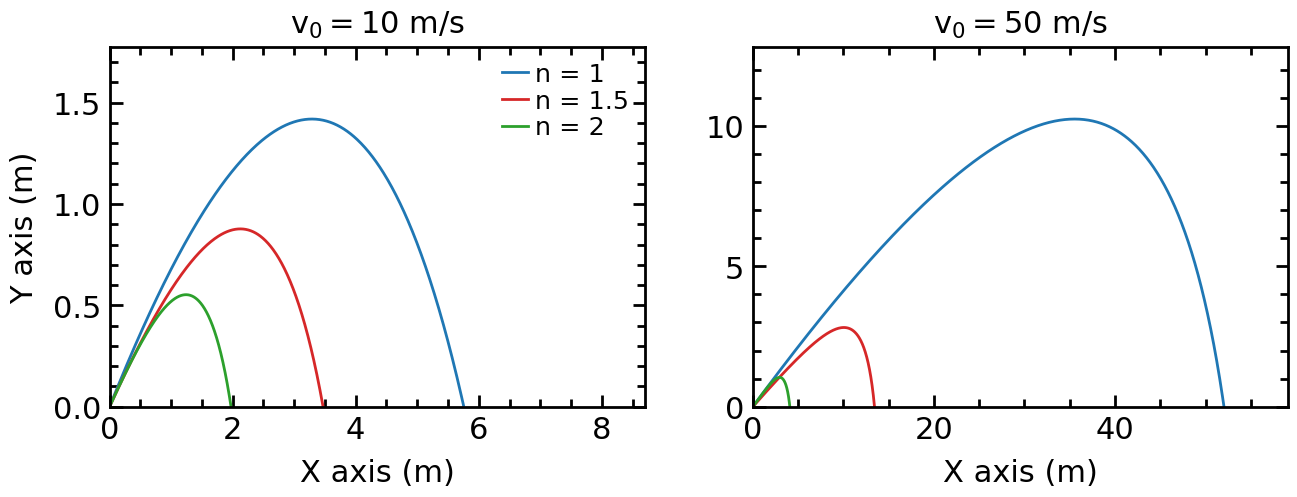

In [68]:
n_power  = [1,1.5,2]
# Tạo 1 hàng 2 cột, chiều rộng 12, chiều cao 5
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors = {1: 'C0', 1.5: 'C1', 2: 'C2'}
k_val = 0.8 # Hệ số ma sát dùng chung cho RK4

for i, v in enumerate(v0_list):
    ax = axes[i]
    
    # 1. Chạy mô phỏng Lý thuyết (k = 0, góc 45 độ là tối ưu chuẩn)
    # Lưu ý: Truyền k=0 thay vì k_friction
    _, x_cal, y_cal, _, _, _, _ = nemxien_comasat(x0, y0, v, 45.0, 0, 1, 1000) 
    x_cal = np.array(x_cal)
    y_cal = np.array(y_cal)
    valid_cal = np.where(y_cal >= 0)[0]
    
    x_maxes = []
    y_maxes = []
    # 2. Chạy mô phỏng RK4 (Có ma sát) với góc tối ưu vừa tìm được
    for n in n_power:
        theta_opt = optimal_data[v][n] # Lấy góc tối ưu tương ứng với v và n
        
        # Chạy lại mô phỏng RK4 với góc tối ưu
        _, x_rk4, y_rk4, _, _, _, _ = nemxien_comasat(x0, y0, v, theta_opt, k_val, n, 1000)
        
        x_rk4 = np.array(x_rk4)
        y_rk4 = np.array(y_rk4)
        valid_idx = np.where(y_rk4 >= 0)[0] # Lọc bỏ phần cắm xuống đất
        
        ax.plot(x_rk4[valid_idx], y_rk4[valid_idx], color=colors[n], linewidth=2, label=f'n = {n}')

        x_maxes.append(np.max(x_rk4))
        y_maxes.append(np.max(y_rk4))

    # 3. Định dạng từng ô đồ thị
    ax.set_xlim(0, np.max(x_maxes)*1.05)
    ax.set_ylim(0, np.max(y_maxes)*1.25 )
    if i == 0:
        ax.set_ylabel('Y axis (m)')
    
        ax.legend(loc = 'upper right', fontsize='small',
        labelspacing=0.1,    # Thu hẹp khoảng cách dòng giữa các nhãn
        handletextpad=0.3,  # Thu hẹp khoảng cách giữa icon màu và chữ
        borderpad=0.1,      # Thu hẹp khoảng cách từ nội dung đến khung viền
        handlelength= 1    # Rút ngắn độ dài của cái đường kẻ/ô màu đại diện 
        )
    ax.set_xlabel('X axis (m)')

    # --- Code mới thêm vào: Chèn ký hiệu (a), (b) ---
    # label = '(a)' if i == 0 else '(b)'
    # ax.set_xlabel(f'X axis (m)\n\n{label}')
     
    ax.set_title(f'$v_0 = {v}$ m/s')
    # ax.legend(loc='upper right', fontsize=10)
    # ax.grid(True, linestyle=':', alpha=0.7)


plt.tight_layout(pad = 2.0)
plt.savefig('4d_Optimal_Trajectories.pdf', bbox_inches='tight')
plt.show()

# code ve cho hinh 5

<>:39: SyntaxWarning: invalid escape sequence '\c'
<>:39: SyntaxWarning: invalid escape sequence '\c'
C:\Users\admin\AppData\Local\Temp\ipykernel_23696\857553128.py:39: SyntaxWarning: invalid escape sequence '\c'
  ax.plot(x_valid, y_valid, color=colors[i], linewidth=2, label=f'$\\theta_0 = {theta}^\circ$')


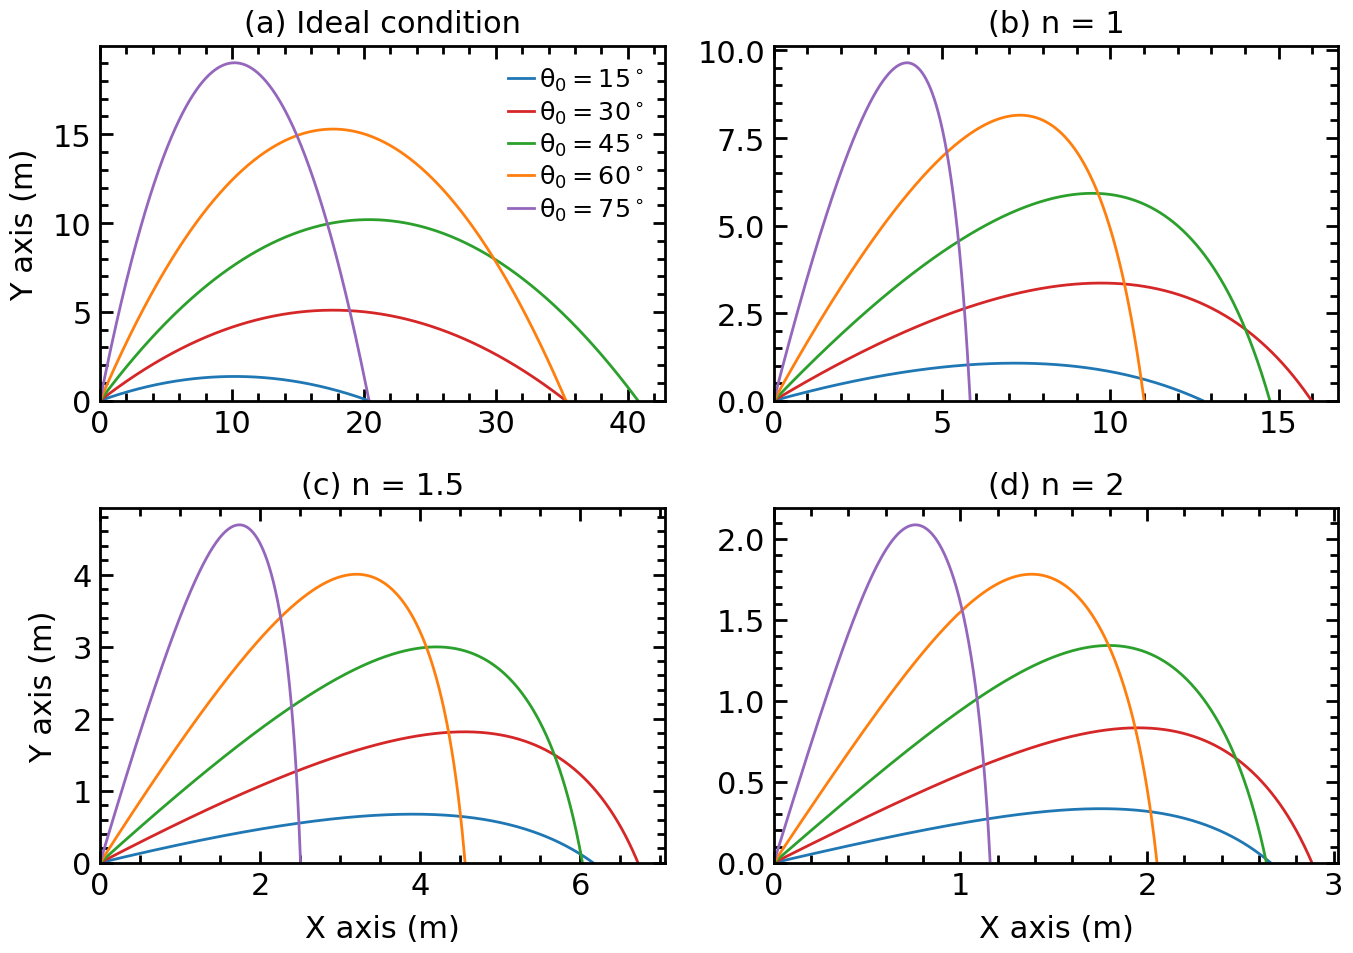

In [55]:
v0 = 20.0 # Sửa v0 để vẽ các họ quỹ đạo
x0 = 0
y0 = 0
g = 9.81
goc_nem_list = [15, 30, 45, 60, 75] 
colors = ['C0', 'C1', 'C2', 'C3', 'C4'] # Bảng màu phân biệt các góc

# 2. Tạo khung đồ thị 2x2
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Danh sách các cấu hình (k, n, tiêu đề, vị trí vẽ trên axes)
configs = [
    (0,   1,   '(a) Ideal condition', axes[0, 0]),
    (0.8, 1,   '(b) n = 1',        axes[0, 1]),
    (0.8, 1.5, '(c) n = 1.5',      axes[1, 0]),
    (0.8, 2,   '(d) n = 2',        axes[1, 1])
]

# 3. Vòng lặp vẽ cả 4 họ quỹ đạo
for k_friction, n_power, title, ax in configs:
    x_max_list = []
    
    for i, theta in enumerate(goc_nem_list):
        # Hứng đúng 7 biến, bỏ qua 4 biến cuối (vận tốc và lực)
        t, x, y, _, _, _, _ = nemxien_comasat(x0, y0, v0, theta, k_friction, n_power, 1000)
        
        x = np.array(x)
        y = np.array(y)
        
        # Cắt bỏ phần âm dưới mặt đất
        valid_idx = np.where(y >= 0)[0]
        x_valid = x[valid_idx]
        y_valid = y[valid_idx]
        
        if len(x_valid) > 0:
            x_max_list.append(max(x_valid))
            
        # Plot đường bay
        ax.plot(x_valid, y_valid, color=colors[i], linewidth=2, label=f'$\\theta_0 = {theta}^\circ$')

    # Căn chỉnh trục và định dạng cho từng ô phụ
    if x_max_list:
        ax.set_xlim(0, max(x_max_list) * 1.05)
    ax.set_ylim(bottom=0)
    
    if ax == axes[1,0] or ax == axes[1,1]:
        ax.set_xlabel('X axis (m)')
    if ax == axes[0,0] or ax == axes[1,0]:
        ax.set_ylabel('Y axis (m)')
    ax.set_title(title)
    # ax.legend(loc='upper right', fontsize=10)
    # ax.grid(True, linestyle=':', alpha=0.7)

    if ax == axes[0,0]:
        ax.legend(loc = 'upper right', fontsize='small',
    labelspacing=0.2,    # Thu hẹp khoảng cách dòng giữa các nhãn
    handletextpad=0.2,  # Thu hẹp khoảng cách giữa icon màu và chữ
    borderpad=0.3,      # Thu hẹp khoảng cách từ nội dung đến khung viền
    handlelength=1.0    # Rút ngắn độ dài của cái đường kẻ/ô màu đại diện 
    )


plt.tight_layout()
plt.savefig('6.pdf', bbox_inches='tight')
plt.show()